# Fine-tune Sentiment (SmSA) + Hyperparameter Tuning -> Apply ke Detik

## Latar Belakang

Selain kategori, setiap artikel dilengkapi dengan label sentimen sebagai metadata tambahan. Pada sistem RAG, metadata sentimen ini berfungsi untuk penyaringan dan agregasi, misalnya untuk menjawab pertanyaan yang menuntut nuansa opini seperti "berita positif" atau untuk merangkum kecenderungan sentimen pada suatu topik. Karena tidak tersedia dataset berita berbahasa Indonesia berlabel sentimen dalam skala memadai, digunakan dataset SmSA dari IndoNLU (sekitar 11.000 sampel, 3 kelas: positif, netral, negatif) sebagai data pelatihan, dengan model IndoBERT yang di-fine-tune untuk tugas ini.

## Tujuan

Tahap ini bertujuan melatih model analisis sentimen berbasis IndoBERT pada dataset SmSA melalui pencarian hyperparameter (tiga nilai learning rate), memilih konfigurasi terbaik, lalu menerapkannya pada artikel Detik untuk menghasilkan label sentimen sebagai metadata.

## Alur Proses

1. Memuat dataset SmSA langsung dari berkas CSV, karena pemuatan melalui pustaka `datasets` versi terbaru sudah tidak didukung.
2. Melakukan tokenisasi teks sesuai format masukan IndoBERT.
3. Menjalankan pencarian hyperparameter dengan melatih tiga learning rate (2e-5, 3e-5, dan 5e-5), lalu memilih model dengan F1-macro validasi tertinggi.
4. Mengevaluasi model terbaik pada test set.
5. Menyimpan model terbaik ke `models/sentiment_indobert/`.
6. Menerapkan model pada `articles_clean.csv` untuk menghasilkan `articles_with_sentiment.csv`.
7. Melakukan eksplorasi dan inspeksi terhadap hasil pelabelan sentimen.

## Catatan dan Keterbatasan

Perlu dicatat secara jujur bahwa SmSA bersumber dari ulasan (review), bukan berita, sehingga terjadi domain shift ketika model diterapkan pada teks berita. Akibatnya, label sentimen yang dihasilkan tidak selalu mencerminkan valensi peristiwa secara tepat dan lebih menangkap nada permukaan teks. Oleh karena itu, sentimen dalam penelitian ini diposisikan sebagai metadata pelengkap, bukan komponen utama sistem. Tahap ini memerlukan akselerasi GPU dan mensyaratkan berkas `articles_clean.csv` hasil pemrosesan telah tersedia.

In [1]:
!pip install -q transformers torch datasets scikit-learn pandas matplotlib accelerate

In [2]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

def find_project_root():
    cwd = Path.cwd().resolve()
    if (cwd / "data").exists() and (cwd / "notebooks").exists():
        return cwd
    for parent in cwd.parents:
        if (parent / "data").exists() and (parent / "notebooks").exists():
            return parent
    return cwd

PROJECT_ROOT = find_project_root()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
for d in [DATA_PROCESSED, MODELS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\user\news-rag-project


Tahap ini menyiapkan kebutuhan dasar sebelum pelatihan dijalankan. Pustaka yang dimuat mencakup `pandas` dan `numpy` untuk pengolahan data, `tqdm` untuk memantau progres, serta `matplotlib` untuk visualisasi. Lokasi root proyek dideteksi secara otomatis agar jalur berkas tetap konsisten, dan folder yang dibutuhkan untuk data terproses (`data/processed`), penyimpanan model (`models`), serta visualisasi (`reports/figures`) disiapkan sekaligus.

## Load SmSA (CSV via pandas)

In [3]:
BASE = ("https://raw.githubusercontent.com/crypter70/"
        "Sentiment-Analysis-with-IndoBERT-Fine-tuning-and-IndoNLU-SmSA-Dataset/main/dataset")

train_df = pd.read_csv(f"{BASE}/train.csv")
valid_df = pd.read_csv(f"{BASE}/validation.csv")
test_df  = pd.read_csv(f"{BASE}/test.csv")

for df in [train_df, valid_df, test_df]:
    if "Unnamed: 0" in df.columns:
        df.drop(columns=["Unnamed: 0"], inplace=True)
train_df = train_df[["text", "label"]].dropna().reset_index(drop=True)
valid_df = valid_df[["text", "label"]].dropna().reset_index(drop=True)
test_df  = test_df[["text", "label"]].dropna().reset_index(drop=True)
for df in [train_df, valid_df, test_df]:
    df["label"] = df["label"].astype(int)

ID2LABEL = {0: "positif", 1: "netral", 2: "negatif"}
LABEL2ID = {"positif": 0, "netral": 1, "negatif": 2}

print(f"Train: {train_df.shape} | Valid: {valid_df.shape} | Test: {test_df.shape}")
print(f"\nDistribusi label train:")
print(train_df["label"].value_counts().sort_index())
for _, r in train_df.head(3).iterrows():
    print(f"  [{ID2LABEL[r['label']]}] {r['text'][:75]}")

Train: (11000, 2) | Valid: (1260, 2) | Test: (500, 2)

Distribusi label train:
label
0    6416
1    1148
2    3436
Name: count, dtype: int64
  [positif] warung ini dimiliki oleh pengusaha pabrik tahu yang sudah puluhan tahun ter
  [netral] mohon ulama lurus dan k212 mmbri hujjah partai apa yang harus diwlh agar su
  [positif] lokasi strategis di jalan sumatera bandung . tempat nya nyaman terutama sof


Dataset SmSA dimuat langsung dari berkas CSV pada mirror yang masih aktif, karena loader bawaan pustaka `datasets` (indonlp/indonlu, SEACrowd) berbasis skrip dan tidak lagi didukung pada versi terbaru, sementara sumber GitHub aslinya tidak dapat diakses. Setelah dibersihkan, dataset terdiri dari 11.000 sampel latih, 1.260 validasi, dan 500 uji, dengan tiga label sentimen (0 = positif, 1 = netral, 2 = negatif).

Pemeriksaan distribusi label pada data latih menunjukkan ketidakseimbangan kelas: sentimen positif paling dominan (6.416), diikuti negatif (3.436), sedangkan netral merupakan kelas minoritas dengan jumlah jauh lebih sedikit (1.148). Ketidakseimbangan ini perlu diperhatikan karena berpotensi memengaruhi performa model pada kelas minoritas, sehingga evaluasi nantinya menekankan F1-macro agar setiap kelas tetap dinilai secara setara.

## Tokenize

In [4]:
import torch
from datasets import Dataset
from transformers import AutoTokenizer

MODEL_NAME = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

def to_ds(df):
    ds = Dataset.from_pandas(df).map(tokenize_fn, batched=True)
    return ds.remove_columns(["text"]).rename_column("label", "labels")

train_ds, valid_ds, test_ds = to_ds(train_df), to_ds(valid_df), to_ds(test_df)
print("Tokenisasi selesai.")
print(f"Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")

Map:   0%|          | 0/11000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1260 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenisasi selesai.
Device: GPU


Teks pada ketiga subset data ditokenisasi menggunakan tokenizer IndoBERT (`indobenchmark/indobert-base-p1`), model dasar yang akan di-fine-tune. Tokenisasi diterapkan dengan pemotongan (truncation) pada panjang maksimum 128 token, yang memadai untuk teks ulasan SmSA yang umumnya pendek. Data kemudian dikonversi ke format Dataset Hugging Face agar siap digunakan dalam proses pelatihan, dengan pelatihan dijalankan pada GPU. 

## Pencarian Hyperparameter (Learning Rate)

Untuk memperoleh konfigurasi terbaik, dilakukan pencarian hyperparameter pada tiga nilai learning rate yang direkomendasikan oleh Devlin et al. (2019) untuk tahap fine-tuning BERT, yaitu 2e-5, 3e-5, dan 5e-5, dengan jumlah epoch (3) dan ukuran batch (16) dibuat tetap. Rekomendasi ini berasal dari prosedur fine-tuning pada paper BERT, yang menyarankan pencarian atas learning rate {5e-5, 3e-5, 2e-5}, batch size {16, 32}, dan epoch {2, 3, 4}, lalu memilih model dengan performa terbaik pada development set. Agar perbandingan adil dan dapat direproduksi, seed (42) ditetapkan ulang sebelum setiap konfigurasi dilatih sehingga inisialisasi lapisan klasifikasi dan pengacakan data identik di semua percobaan. Setiap konfigurasi dievaluasi pada data validasi, dan model dengan F1-macro tertinggi dipilih sebagai model terbaik melalui mekanisme `load_best_model_at_end`.

### Referensi:
Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. In Proceedings of NAACL-HLT 2019 (pp. 4171-4186). arXiv:1810.04805.

In [5]:
from transformers import (AutoModelForSequenceClassification, TrainingArguments,
                          Trainer, DataCollatorWithPadding, set_seed)
from sklearn.metrics import accuracy_score, f1_score

SEED = 42
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds),
            "f1_macro": f1_score(labels, preds, average="macro")}

SEARCH_SPACE = [2e-5, 3e-5, 5e-5]   # 3 learning rate
EPOCHS = 3                          # turunin ke 2 kalau mau lebih cepat

results = []
best = {"f1": -1.0, "lr": None, "trainer": None}

for lr in SEARCH_SPACE:
    print(f"\n{'='*45}\n  TRAINING lr={lr}\n{'='*45}")
    set_seed(SEED)   # init head & shuffling identik tiap config -> adil + reproducible
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID)
    args = TrainingArguments(
        output_dir=str(MODELS_DIR / f"ckpt_lr{lr}"),
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=lr,
        seed=SEED,
        data_seed=SEED,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        save_total_limit=1,
        logging_steps=100,
        fp16=torch.cuda.is_available(),
        report_to="none",
    )
    trainer = Trainer(model=model, args=args, train_dataset=train_ds,
                      eval_dataset=valid_ds, tokenizer=tokenizer,
                      data_collator=data_collator, compute_metrics=compute_metrics)
    trainer.train()
    val = trainer.evaluate(valid_ds)
    print(f">> lr={lr}: val_acc={val['eval_accuracy']:.4f}, val_f1={val['eval_f1_macro']:.4f}")
    results.append({"lr": lr, "val_accuracy": round(val["eval_accuracy"], 4),
                    "val_f1_macro": round(val["eval_f1_macro"], 4)})
    if val["eval_f1_macro"] > best["f1"]:
        if best["trainer"] is not None:
            del best["trainer"]; torch.cuda.empty_cache()
        best = {"f1": val["eval_f1_macro"], "lr": lr, "trainer": trainer}
    else:
        del trainer, model; torch.cuda.empty_cache()

print("\n=== Hasil Hyperparameter Search ===")
print(pd.DataFrame(results).to_string(index=False))
print(f"\nBEST: lr={best['lr']} (val f1_macro={best['f1']:.4f})")

trainer = best["trainer"]   # best model dipakai di step berikutnya


  TRAINING lr=2e-05


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\user\AppData\Local\Temp\ipykernel_44172\2733937539.py:42: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, args=args, train_dataset=train_ds,


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.198400,0.207171,0.932540,0.904539
2,0.127600,0.205018,0.938889,0.909180
3,0.057400,0.270178,0.941270,0.915050


>> lr=2e-05: val_acc=0.9413, val_f1=0.9150

  TRAINING lr=3e-05


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\user\AppData\Local\Temp\ipykernel_44172\2733937539.py:42: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, args=args, train_dataset=train_ds,


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.212600,0.218432,0.933333,0.906034
2,0.134400,0.221053,0.932540,0.905364
3,0.047400,0.306379,0.934127,0.909021


>> lr=3e-05: val_acc=0.9341, val_f1=0.9090

  TRAINING lr=5e-05


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\user\AppData\Local\Temp\ipykernel_44172\2733937539.py:42: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, args=args, train_dataset=train_ds,


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.247600,0.268005,0.928571,0.893254
2,0.139000,0.237393,0.930159,0.896116
3,0.060600,0.296607,0.934921,0.909355


>> lr=5e-05: val_acc=0.9349, val_f1=0.9094

=== Hasil Hyperparameter Search ===
     lr  val_accuracy  val_f1_macro
0.00002        0.9413        0.9150
0.00003        0.9341        0.9090
0.00005        0.9349        0.9094

BEST: lr=2e-05 (val f1_macro=0.9150)


Hasil pencarian menunjukkan ketiga konfigurasi mencapai performa yang berdekatan, dengan F1-macro validasi pada kisaran 0,909 hingga 0,915. Konfigurasi dengan learning rate 2e-5 memberikan hasil terbaik, yaitu akurasi validasi 0,9413 dan F1-macro 0,9150, sehingga dipilih untuk dievaluasi pada test set dan diterapkan pada artikel Detik.

## Best Model di Test Set

=== Test Set SmSA (best lr=2e-05) ===
Accuracy : 0.9140
F1 macro : 0.8882

              precision    recall  f1-score   support

     positif       0.91      0.94      0.93       208
      netral       0.92      0.69      0.79        88
     negatif       0.91      0.98      0.95       204

    accuracy                           0.91       500
   macro avg       0.92      0.87      0.89       500
weighted avg       0.91      0.91      0.91       500



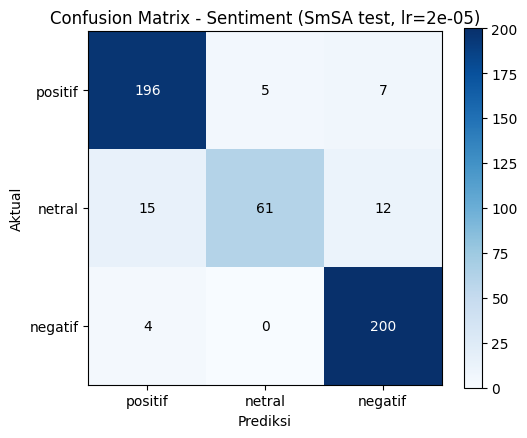


Saved -> C:\Users\user\news-rag-project\reports\figures\sentiment_confusion_matrix.png


In [6]:
from sklearn.metrics import classification_report, confusion_matrix

pred_out = trainer.predict(test_ds)
y_pred = np.argmax(pred_out.predictions, axis=-1)
y_true = pred_out.label_ids

print(f"=== Test Set SmSA (best lr={best['lr']}) ===")
print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"F1 macro : {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"\n{classification_report(y_true, y_pred, target_names=['positif','netral','negatif'])}")

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cm, cmap="Blues")
labels = ["positif", "netral", "negatif"]
ax.set_xticks(range(3)); ax.set_xticklabels(labels)
ax.set_yticks(range(3)); ax.set_yticklabels(labels)
ax.set_xlabel("Prediksi"); ax.set_ylabel("Aktual")
ax.set_title(f"Confusion Matrix - Sentiment (SmSA test, lr={best['lr']})")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im); plt.tight_layout()
plt.savefig(FIG_DIR / "sentiment_confusion_matrix.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"\nSaved -> {FIG_DIR / 'sentiment_confusion_matrix.png'}")

Model terbaik (learning rate 2e-5) dievaluasi pada test set SmSA. Model mencapai akurasi 0,9140 dan F1-macro 0,8882, yang tergolong baik untuk klasifikasi sentimen tiga kelas. Secara per kelas, performa pada sentimen positif dan negatif sangat kuat (F1 masing-masing 0,93 dan 0,95 dengan recall tinggi), sedangkan kelas netral menjadi yang terlemah dengan recall hanya 0,69.

Confusion matrix mengonfirmasi pola ini: sebagian sampel netral salah diklasifikasikan sebagai positif maupun negatif. Kelemahan pada kelas netral konsisten dengan ketidakseimbangan kelas yang teridentifikasi sebelumnya (netral merupakan kelas minoritas) sekaligus mencerminkan sifat sentimen netral yang secara alami lebih ambigu dan berada di antara kedua kutub lainnya. Selisih antara akurasi dan F1-macro juga menegaskan pentingnya menggunakan F1-macro sebagai metrik utama agar performa pada kelas minoritas tetap terwakili secara adil.

## Simpan Best Model

In [7]:
save_path = MODELS_DIR / "sentiment_indobert"
trainer.save_model(str(save_path))
tokenizer.save_pretrained(str(save_path))
print(f"Best model (lr={best['lr']}) disimpan -> {save_path}")

Best model (lr=2e-05) disimpan -> C:\Users\user\news-rag-project\models\sentiment_indobert


Model terbaik beserta tokenizer-nya disimpan ke `models/sentiment_indobert/`, sehingga dapat dimuat kembali untuk menerapkan pelabelan sentimen pada artikel Detik tanpa perlu melatih ulang.

## Terapkan ke Artikel Detik

In [8]:
from transformers import pipeline

df_articles = pd.read_csv(DATA_PROCESSED / "articles_clean.csv")
print(f"Artikel: {len(df_articles)}")

device = 0 if torch.cuda.is_available() else -1
clf = pipeline("text-classification", model=str(save_path),
               tokenizer=str(save_path), device=device,
               truncation=True, max_length=512)

texts = df_articles["isi"].tolist()
batch_size = 32 if device == 0 else 8
preds = []
for i in tqdm(range(0, len(texts), batch_size), desc="Sentiment Detik"):
    preds.extend(clf(texts[i:i+batch_size]))

df_articles["sentiment"] = [p["label"] for p in preds]
df_articles["sentiment_score"] = [p["score"] for p in preds]

print(f"\nDistribusi sentiment artikel Detik:")
print(df_articles["sentiment"].value_counts())

out_path = DATA_PROCESSED / "articles_with_sentiment.csv"
df_articles.to_csv(out_path, index=False)
print(f"\nSaved -> {out_path} ({df_articles.shape})")

Artikel: 1840


Device set to use cuda:0


Sentiment Detik:   0%|          | 0/58 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



Distribusi sentiment artikel Detik:
sentiment
netral     898
negatif    494
positif    448
Name: count, dtype: int64

Saved -> C:\Users\user\news-rag-project\data\processed\articles_with_sentiment.csv ((1840, 9))


Model sentimen yang telah dilatih kemudian diterapkan pada 1.840 artikel bersih (`articles_clean.csv`) untuk menghasilkan label sentimen sebagai metadata. Inferensi dilakukan secara batch menggunakan pipeline klasifikasi, dengan panjang maksimum 512 token agar mengakomodasi isi artikel berita yang lebih panjang dibandingkan teks ulasan SmSA. Setiap artikel memperoleh label sentimen beserta skor keyakinannya, lalu hasilnya disimpan ke `articles_with_sentiment.csv`.

Distribusi sentimen pada artikel Detik didominasi oleh netral (898), diikuti negatif (494) dan positif (448). Dominasi label netral ini wajar mengingat sebagian besar berita bersifat faktual dan tidak bermuatan opini kuat. Sejalan dengan catatan domain shift sebelumnya, label-label ini lebih mencerminkan nada permukaan teks dan diposisikan sebagai metadata pelengkap pada sistem RAG, bukan penilaian valensi peristiwa yang mutlak.

## EDA + Inspeksi

sentiment  negatif  netral  positif
kategori                           
finance       19.7    65.3     14.9
health        46.4    39.7     14.0
inet          25.6    46.0     28.4
news          30.0    57.2     12.8
sport         13.7    34.2     52.2


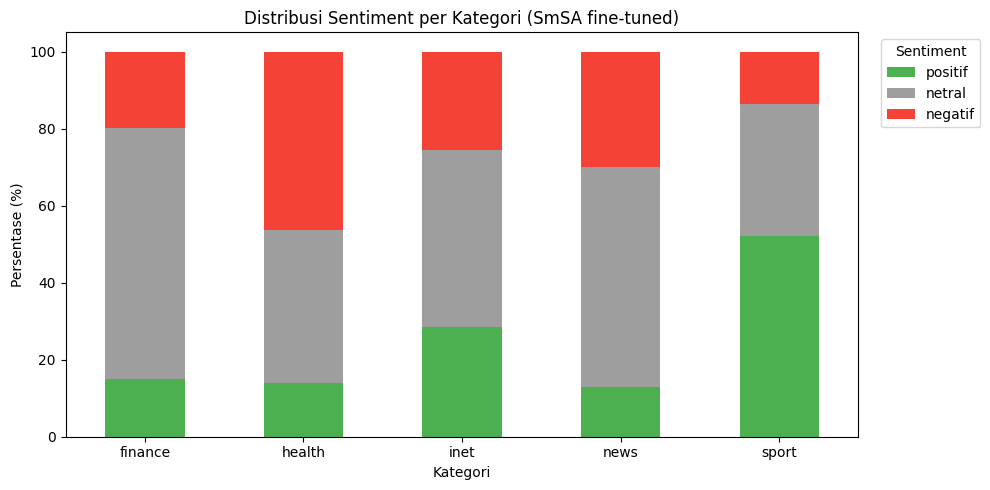

In [9]:
crosstab = pd.crosstab(df_articles["kategori"], df_articles["sentiment"], normalize="index") * 100
print(crosstab.round(1))

fig, ax = plt.subplots(figsize=(10, 5))
color_map = {"positif": "#4CAF50", "netral": "#9E9E9E", "negatif": "#F44336"}
cols = [c for c in ["positif", "netral", "negatif"] if c in crosstab.columns]
crosstab[cols].plot(kind="bar", stacked=True, ax=ax, color=[color_map[c] for c in cols])
ax.set_title("Distribusi Sentiment per Kategori (SmSA fine-tuned)")
ax.set_xlabel("Kategori"); ax.set_ylabel("Persentase (%)")
ax.legend(title="Sentiment", bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(FIG_DIR / "sentiment_per_kategori.png", dpi=100, bbox_inches="tight")
plt.show()

Untuk memahami pola sentimen antarkanal, dibuat tabulasi silang antara kategori dan sentimen dalam bentuk persentase. Hasilnya menunjukkan kecenderungan yang masuk akal dan sesuai intuisi: kategori sport paling positif (52,2% positif), sejalan dengan berita prestasi dan kemenangan; health paling negatif (46,4%), mencerminkan pemberitaan seputar penyakit dan masalah kesehatan; sementara finance dan news didominasi netral (masing-masing 65,3% dan 57,2%), sesuai sifat berita ekonomi dan umum yang cenderung faktual.

Pola yang selaras dengan intuisi ini memberikan validitas tampak (face validity) terhadap label sentimen di tingkat kategori. Meskipun terdapat domain shift dari data ulasan ke berita, kecenderungan agregat per kanal tetap wajar, sehingga label sentimen layak digunakan sebagai metadata pendukung pada sistem RAG.

## Inspeksi Kualitatif Label Sentimen

In [10]:
def lead(text, n=2):
    parts = re.split(r"(?<=[.!?])\s+", str(text))
    return " ".join(parts[:n]).strip()

for cat in sorted(df_articles["kategori"].unique()):
    print("=" * 70); print(f"KATEGORI: {cat}"); print("=" * 70)
    for sent in ["positif", "netral", "negatif"]:
        subset = df_articles[(df_articles["kategori"] == cat) & (df_articles["sentiment"] == sent)]
        if len(subset) == 0:
            continue
        print(f"\n  --- {sent.upper()} ({len(subset)}) ---")
        for _, r in subset.head(2).iterrows():
            print(f"  [score {r['sentiment_score']:.2f}] {r['judul'][:60]}")
            print(f"     {lead(r['isi'])[:110]}...")
    print()

KATEGORI: finance

  --- POSITIF (56) ---
  [score 0.98] 80 Ton Udang dari Kebumen Siap Diekspor ke AS
     Presiden Prabowo Subianto ikut langsung memanen udang Budi Daya Udang Berbasis Kawasan (BUBK) Kebumen di Jawa ...
  [score 0.71] CT Bagi 3 Jurus Mulai Bisnis Tanpa Modal Satu Rupiah Pun
     Founder and Chairman CT Corp Chairul Tanjung membagikan pengalaman membangun bisnis dari nol, dalam education ...

  --- NETRAL (245) ---
  [score 1.00] IHSG Dibuka Dua Arah Pagi Ini, Balik Menguat ke 6.148
     Indeks Harga Saham Gabungan (IHSG) pada perdagangan hari ini dibuka melemah. IHSG kemudian bergerak ke zona hi...
  [score 1.00] Jelang Libur Panjang, IHSG Sempat Dibuka Merah Lalu ke Zona 
     Indeks Harga Saham Gabungan (IHSG) dibuka melemah pada perdagangan hari ini. Tidak lama kemudian, IHSG bergera...

  --- NEGATIF (74) ---
  [score 0.77] Bahlil Jamin Tak Ada Pemangkasan Kuota Ekspor Gas
     Menteri Energi dan Sumber Daya Mineral (ESDM) Bahlil Lahadalia memastikan pemerintah t

Inspeksi kualitatif dilakukan dengan meninjau contoh artikel berskor tinggi pada tiap kombinasi kategori dan sentimen. Sebagian besar label tampak masuk akal, terutama pada kelas netral berkeyakinan tinggi untuk berita faktual (misalnya laporan pergerakan IHSG dan jadwal pertandingan) serta label positif pada berita prestasi dan peluncuran produk. Hal ini menunjukkan model cukup andal menangkap nada teks pada kasus yang lugas.

Namun, ditemukan pula sejumlah kesalahan pelabelan yang menegaskan adanya domain shift dari data ulasan ke berita. Model cenderung membaca nada permukaan teks, bukan valensi peristiwa yang sebenarnya. Sebagai contoh, berita "Prancis Dilanda Gelombang Panas, 7 Orang Tewas" dilabeli netral karena ditulis dengan gaya pelaporan faktual, padahal peristiwanya negatif; sebaliknya, berita olahraga "MotoGP Catalunya 2026: Diggia Jatuh Dihantam Ban, Juara..." dilabeli negatif akibat kata "jatuh" dan "dihantam", meskipun intinya sang pembalap justru menang. Pola serupa terlihat pada berita finance yang bersifat menenangkan (seperti jaminan tidak adanya pemangkasan kuota) yang justru terbaca negatif. Temuan ini menguatkan kesimpulan bahwa label sentimen bersifat sebagai metadata pendukung yang tidak sempurna pada level artikel, namun tetap memadai untuk kebutuhan penyaringan dan agregasi pada sistem RAG.


Tahap analisis sentimen telah menghasilkan model IndoBERT terlatih yang diterapkan pada seluruh artikel, dengan label sentimen beserta skornya tersimpan pada `articles_with_sentiment.csv` sebagai metadata. Sebagaimana ditegaskan melalui evaluasi dan inspeksi, label ini memiliki keterbatasan akibat domain shift dan diposisikan sebagai metadata pelengkap, bukan komponen utama. Tahap berikutnya membahas pelatihan model klasifikasi kategori, yang menjadi komponen klasifikasi inti untuk mengarahkan proses pencarian (routing) pada sistem RAG.